# 00 Data Sanity

Quick sanity checks for `generate_synthetic_data(...)`.

Note: `cluster_sep` is measured in units of `cluster_std` (sigma units).
For example, `cluster_sep = 3` means approximately 3-sigma center separation when `d >= K`.


In [5]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is importable regardless of notebook/kernel cwd.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = next((p for p in candidates if (p / "moe_bandit").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'moe_bandit'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from moe_bandit.data import generate_synthetic_data, _build_cluster_means


In [6]:
def plot_cluster_mean_distance_heatmap(K, d, cluster_sep, cluster_std, seed=0):
    """Plot KxK heatmap of ||mu_i - mu_j||_2 for cluster means."""
    rng = np.random.default_rng(seed)
    means = _build_cluster_means(
        K=K, d=d, cluster_sep=cluster_sep, cluster_std=cluster_std, rng=rng
    )
    diffs = means[:, None, :] - means[None, :, :]
    dists = np.linalg.norm(diffs, axis=-1)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(dists, cmap="viridis")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{dists[i, j]:.2f}", ha="center", va="center", color="white")
    ax.set_xticks(np.arange(K), labels=[f"cluster {j}" for j in range(K)], rotation=45, ha="right")
    ax.set_yticks(np.arange(K), labels=[f"cluster {i}" for i in range(K)])
    ax.set_xlabel("cluster j")
    ax.set_ylabel("cluster i")
    ax.set_title("pairwise distances between cluster means")
    plt.tight_layout()
    plt.show()


def plot_projection_grid(X, cluster_id, K, d, max_dims=6):
    # For basis-aligned means, each (i, j) view separates clusters i/j; others sit near origin in those dims.
    dims_to_plot = min(d, max_dims)
    fig, axes = plt.subplots(dims_to_plot, dims_to_plot, figsize=(3 * dims_to_plot, 3 * dims_to_plot))
    if dims_to_plot == 1:
        axes = np.array([[axes]])
    for i in range(dims_to_plot):
        for j in range(dims_to_plot):
            ax = axes[i, j]
            if i >= j:
                ax.axis("off")
                continue
            for k in range(K):
                mask = cluster_id == k
                ax.scatter(X[mask, i], X[mask, j], s=8, alpha=0.6, label=f"cluster {k}")
            ax.set_xlabel(f"x[{i}]")
            ax.set_ylabel(f"x[{j}]")
            ax.grid(alpha=0.2)
    handles, labels = axes[0, 1].get_legend_handles_labels() if dims_to_plot > 1 else ([], [])
    if handles:
        fig.legend(handles, labels, loc="upper right")
    if d > max_dims:
        fig.suptitle(f"Upper-triangle projection grid (showing first {max_dims} of {d} dimensions)", y=1.01)
    else:
        fig.suptitle("Upper-triangle projection grid", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_pca_projection(X, cluster_id):
    """Project X to top-2 PCs with NumPy SVD and scatter by cluster_id."""
    X_centered = X - X.mean(axis=0, keepdims=True)
    _, singular_vals, vt = np.linalg.svd(X_centered, full_matrices=False)
    X_pca = X_centered @ vt[:2].T
    eigvals = (singular_vals ** 2) / max(X_centered.shape[0] - 1, 1)
    explained_ratio = eigvals / np.maximum(eigvals.sum(), 1e-12)
    plt.figure(figsize=(7, 6))
    for k in np.unique(cluster_id):
        mask = cluster_id == k
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.65, label=f"cluster {k}")
    plt.xlabel(f"PC1 ({100 * explained_ratio[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({100 * explained_ratio[1]:.1f}% var)")
    plt.title("PCA projection of synthetic contexts")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


In [7]:
# Baseline config from Implementation Plan sanity-check note
n_samples = 1500
K = 4
d = 4
cluster_sep = 3.0
cluster_std = 1.0
seed = 42

X, y, cluster_id = generate_synthetic_data(
    n_samples=n_samples,
    K=K,
    d=d,
    cluster_sep=cluster_sep,
    cluster_std=cluster_std,
    seed=seed,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("cluster_id shape:", cluster_id.shape)
print("y equals cluster_id:", np.array_equal(y, cluster_id))
print("effective center scale (cluster_sep * cluster_std):", cluster_sep * cluster_std)


X shape: (1500, 4)
y shape: (1500,)
cluster_id shape: (1500,)
y equals cluster_id: True
effective center scale (cluster_sep * cluster_std): 3.0


In [8]:
# Quick distribution sanity checks
counts = np.bincount(cluster_id, minlength=K)
print("Cluster counts:", counts)
print("Cluster proportions:", np.round(counts / counts.sum(), 3))


Cluster counts: [367 371 377 385]
Cluster proportions: [0.245 0.247 0.251 0.257]


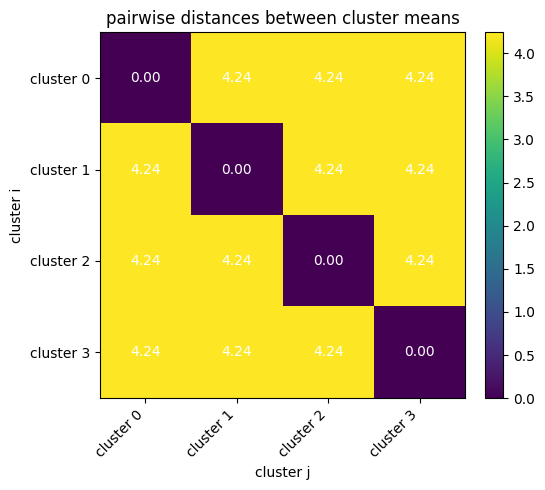

In [9]:
plot_cluster_mean_distance_heatmap(
    K=K, d=d, cluster_sep=cluster_sep, cluster_std=cluster_std, seed=seed
)


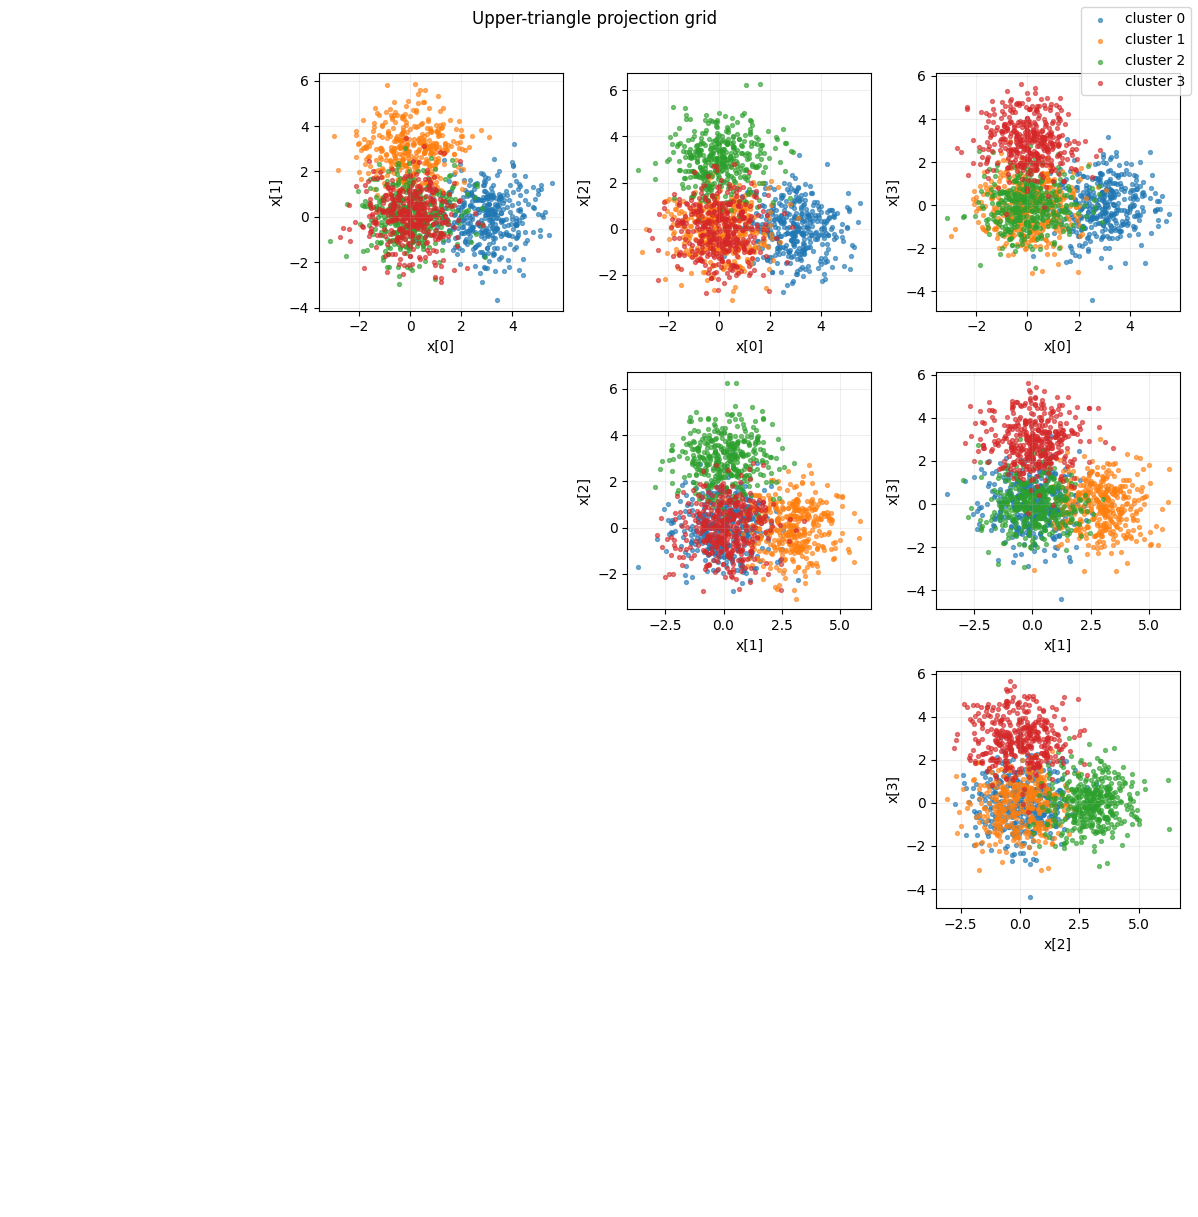

In [10]:
plot_projection_grid(X, cluster_id, K=K, d=d, max_dims=6)


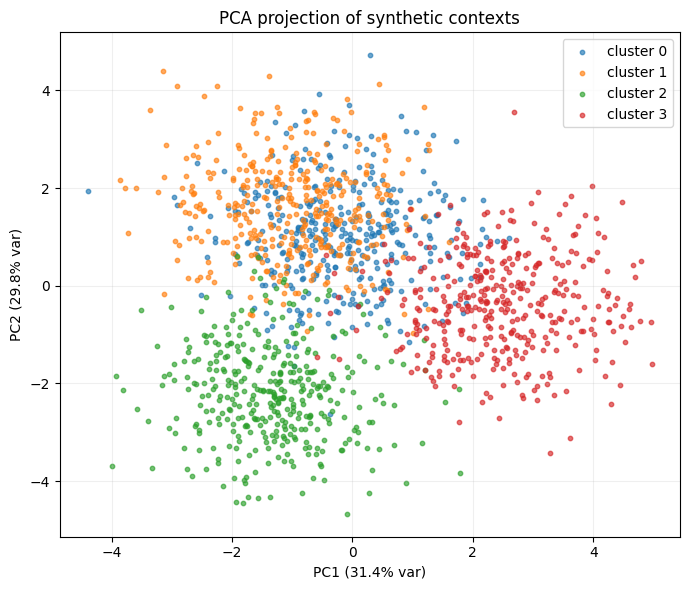

In [11]:
plot_pca_projection(X, cluster_id)


In [12]:
# Reproducibility smoke check
X2, y2, c2 = generate_synthetic_data(
    n_samples=n_samples,
    K=K,
    d=d,
    cluster_sep=cluster_sep,
    cluster_std=cluster_std,
    seed=seed,
)
print("Reproducible X:", np.allclose(X, X2))
print("Reproducible y:", np.array_equal(y, y2))
print("Reproducible cluster_id:", np.array_equal(cluster_id, c2))


Reproducible X: True
Reproducible y: True
Reproducible cluster_id: True
